In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import talib as ta

In [2]:
def load_data(path):
    data = pd.read_csv(path, index_col="datetime", parse_dates=True)
    data = data[data.index <= '2026-03-31']
    return data

dbtc = load_data(path='../data/binance_BTC_USDT_1h.csv')

In [4]:
dbtc.tail(3)

,open,high,low,close,volume
datetime,,,,,
2026-03-30 22:00:00,66809.30,66989.10,66683.72,66784.98,169.50316
2026-03-30 23:00:00,66784.97,66797.38,66419.79,66797.37,698.24190
2026-03-31 00:00:00,66797.38,67303.33,66544.51,67208.75,658.94529


In [5]:
len(dbtc)

63445

In [3]:
dbtc.head(2)

,open,high,low,close,volume
datetime,,,,,
2019-01-01 00:00:00,3701.23,3713.00,3689.88,3700.31,686.367420
2019-01-01 01:00:00,3700.20,3702.73,3684.22,3689.69,613.539115


In [22]:
dbtc.describe()

,open,high,low,close,volume
count,63593.000000,63593.000000,63593.000000,63593.000000,63593.000000
mean,42743.267162,42911.944313,42566.646910,42744.294802,2820.972408
std,32393.687901,32491.005871,32292.917936,32393.491302,4142.178441
min,3366.630000,3386.970000,3349.920000,3366.410000,0.000000
25%,13091.870000,13144.510000,13041.180000,13092.890000,808.755053
50%,34647.350000,34837.930000,34438.950000,34649.630000,1504.844707
75%,63745.840000,63988.000000,63482.760000,63746.110000,3009.722582
max,126011.180000,126199.630000,125252.740000,126011.180000,137207.188600


In [23]:
def plot_price(data):
    plt.plot(data)
    plt.title("Biểu đồ giá Close") 
    plt.xlabel("Thời gian")   
    plt.ylabel("Giá")         
    plt.grid(True)        
    plt.show() 

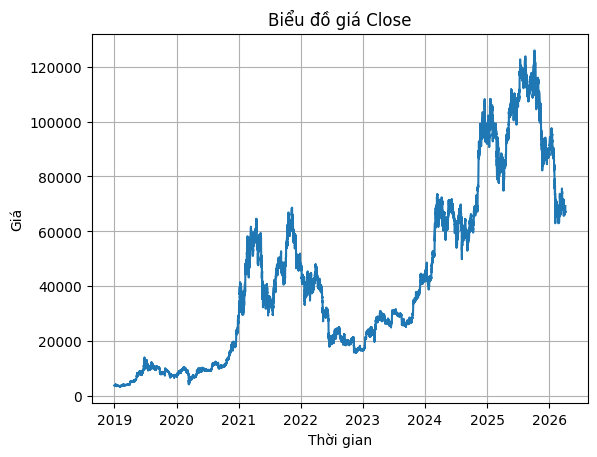

In [24]:
plot_price(dbtc.loc[:, "close"])

In [25]:
def pre_process(df):
    data = df.copy()
    EPSILON = 1e-8
    delta = data.index.to_series().diff()
    delta_time = delta.dt.total_seconds() / 3600
    delta_time = delta_time.fillna(1).astype(int)
    data['log_time_gap'] = np.log(delta_time)
    # 1. Temporal Features
    hours = data.index.hour
    data['hour_sin'] = np.sin(2 * np.pi * hours / 24)
    data['hour_cos'] = np.cos(2 * np.pi * hours / 24)
    # 1. Price structure
    high_low_range = data['high'] - data['low'] + EPSILON
    data['body_ratio'] = (data['close'] - data['open']) / high_low_range
    # 2. Multi-horizon Momentum
    horizons = [1, 4, 24]
    for h in horizons:
        data[f'log_ret_{h}'] = np.log(data['close'] / data['close'].shift(h))
    # 3. Volatility & Risk Representation
    data['volatility_4'] = data['log_ret_1'].rolling(window=4).std()
    volatility_horizons = [24]
    for h in volatility_horizons:
        volatility_h = data['log_ret_1'].rolling(window=h).std()
        data[f'volatility_{h}_ratio'] = data['volatility_4'] / (volatility_h + EPSILON)


    # 4. Microstructure & Volume Dynamics
    typical_price = ta.TYPPRICE(data['high'], data['low'], data['close'])
    tp_vol = typical_price * data['volume']
    rolling_tp_vol = ta.SUM(tp_vol, timeperiod=24)
    rolling_vol = ta.SUM(data['volume'], timeperiod=24)
    vwap_24 = rolling_tp_vol / (rolling_vol + EPSILON)
    data['dist_vwap_24'] = (data['close'] - vwap_24) / (vwap_24 + EPSILON)
    
    # Indicator
    # RSI (Relative Strength Index) - Momentum & Overbought/Oversold
    data['rsi_14'] = ta.RSI(data['close'], timeperiod=14) / 100.0
    # Bollinger Bands %B (Volatility & Price Position)
    upper, middle, lower = ta.BBANDS(data['close'], timeperiod=20, nbdevup=2, nbdevdn=2, matype=0)
    data['bb_percent_b'] = (data['close'] - lower) / (upper - lower + EPSILON)
    # 4. ADX (Average Directional Index) - Trend Strength
    data['adx_14'] = ta.ADX(data['high'], data['low'], data['close'], timeperiod=14) / 100.0
    # 5. MFI (Money Flow Index) - Volume-weighted Momentum
    # MFI thường dao động từ 0-100, chia 100 để đưa về [0, 1]
    data['mfi_14'] = ta.MFI(data['high'], data['low'], data['close'], data['volume'], timeperiod=14) / 100.0
    # 6. Williams %R - Price Position in Range
    # Williams %R mặc định của TA-Lib chạy từ -100 đến 0. 
    # Ta có thể đưa về [0, 1] bằng cách: (giá trị + 100) / 100
    # Hoặc để nguyên từ -1 đến 0 bằng cách chia 100.
    data['williams_r_14'] = (ta.WILLR(data['high'], data['low'], data['close'], timeperiod=14) + 100.0) / 100.0
    
    data = data.loc[(data.index >= '2020-01-01') & (data.index < '2026-04-01')]
    data = data.dropna()
    return data


In [26]:
pdbtc = pre_process(dbtc)
include = pdbtc.columns.to_list()
exclude = ["open", "high", "low", "close", "volume"]
include = [x if x not in exclude else '' for x in include]
k = []
for x in include:
    if x != '':
        k.append(x)
k
des = pdbtc.loc[:, k].describe()
des.to_csv('btc_statistics.csv')
des

,log_time_gap,hour_sin,hour_cos,body_ratio,log_ret_1,log_ret_4,log_ret_24,volatility_4,volatility_24_ratio,dist_vwap_24,rsi_14,bb_percent_b,adx_14,mfi_14,williams_r_14
count,54736.000000,54736.000000,5.473600e+04,54736.000000,54736.000000,54736.000000,54736.000000,54736.000000,54736.000000,54736.000000,54736.000000,54736.000000,54736.000000,5.473600e+04,54736.000000
mean,0.000291,-0.000192,-3.083244e-05,0.011636,0.000041,0.000164,0.000979,0.004891,0.895114,0.000967,0.507962,0.512955,0.275296,5.028659e-01,0.527151
std,0.018736,0.707103,7.071236e-01,0.496053,0.006671,0.013044,0.031927,0.004608,0.474301,0.015673,0.121491,0.335097,0.119019,1.752036e-01,0.264178
min,0.000000,-1.000000,-1.000000e+00,-1.000000,-0.201033,-0.342863,-0.624510,0.000062,0.017288,-0.297458,0.055606,-0.563136,0.065581,-3.282749e-15,0.000000
25%,0.000000,-0.707107,-7.071068e-01,-0.408345,-0.002325,-0.004517,-0.012818,0.002145,0.536090,-0.006256,0.430562,0.262458,0.185642,3.747765e-01,0.304000
50%,0.000000,0.000000,-1.836970e-16,0.014229,0.000061,0.000173,0.000901,0.003663,0.812270,0.000696,0.507592,0.524321,0.250841,5.020322e-01,0.535023
75%,0.000000,0.707107,7.071068e-01,0.432069,0.002504,0.005035,0.015159,0.006164,1.174066,0.007954,0.584763,0.763789,0.344647,6.301740e-01,0.754976
max,1.791759,1.000000,1.000000e+00,1.000000,0.160280,0.182272,0.283191,0.151467,2.653328,0.107595,0.958543,1.575102,0.827642,1.000000e+00,1.000000


In [27]:
from statsmodels.tsa.stattools import adfuller
import pandas as pd

def check_stationarity(df):
    # Danh sách các cột loại trừ
    exclude_cols = ['open', 'high', 'low', 'close', 'volume', 
                    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']
    
    # Lấy danh sách các feature cần test
    feature_cols = [c for c in df.columns if c not in exclude_cols]
    
    results = []
    
    print(f"--- Đang kiểm tra tính dừng cho {len(feature_cols)} features ---")
    
    for col in feature_cols:
        # ADF test yêu cầu không có giá trị NaN
        series = df[col].dropna()
        
        # Thực hiện bài test ADF
        # regression='c' là test với một hằng số (phổ biến nhất)
        res = adfuller(series, autolag='AIC')
        
        adf_stat = res[0]
        p_value = res[1]
        critical_value_5 = res[4]['5%']
        
        # Một feature được coi là "Dừng" nếu p-value < 0.05
        is_stationary = p_value < 0.05
        
        results.append({
            'Feature': col,
            'ADF Statistic': round(adf_stat, 4),
            'p-value': round(p_value, 4),
            'Stationary': '✅ Yes' if is_stationary else '❌ No'
        })
    
    # Trả về DataFrame kết quả để dễ quan sát
    return pd.DataFrame(results)

stationarity_report = check_stationarity(pdbtc)
print(stationarity_report)

--- Đang kiểm tra tính dừng cho 13 features ---
                Feature  ADF Statistic  p-value Stationary
0          log_time_gap      -234.0073      0.0      ✅ Yes
1            body_ratio       -38.2286      0.0      ✅ Yes
2             log_ret_1       -32.4534      0.0      ✅ Yes
3             log_ret_4       -30.0480      0.0      ✅ Yes
4            log_ret_24       -25.5288      0.0      ✅ Yes
5          volatility_4       -16.0757      0.0      ✅ Yes
6   volatility_24_ratio       -39.9209      0.0      ✅ Yes
7          dist_vwap_24       -28.6178      0.0      ✅ Yes
8                rsi_14       -31.7107      0.0      ✅ Yes
9          bb_percent_b       -40.7129      0.0      ✅ Yes
10               adx_14       -36.0023      0.0      ✅ Yes
11               mfi_14       -27.0887      0.0      ✅ Yes
12        williams_r_14       -43.5783      0.0      ✅ Yes
